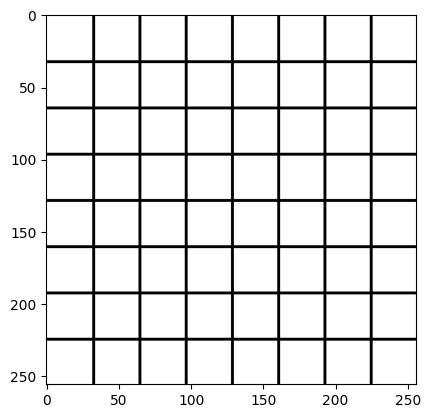

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

size = 256
step = int((size)/8)

xd = set([0,1])

arr = [[255 if ( i%step not in xd) else 255 if i < 2 else 0 for i in range(size)] for _ in range(size)]

for i in range(step, size, step):
	arr[i] = [0] * size
	arr[i+1] = [0] * size


cuad = np.array(arr).reshape(size,size)

plt.imshow(cuad,cmap="gray", vmin=0,vmax=255)
plt.show()


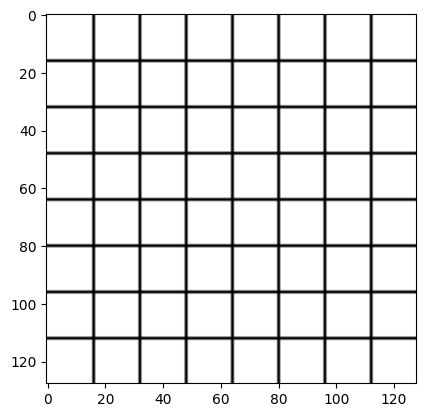

In [2]:

cuad_r =  cv2.resize(cuad, (128,128), interpolation=cv2.INTER_NEAREST)
plt.imshow(cuad_r, cmap='gray', vmin=0, vmax=255)
plt.show()

Ahora la resolución de la imagen es el mitad de la original. Esto se debe a que se mantiene el espacio físico de la imagen, sin embargo, ahora cada pixel representa una porción mayor de la imagen original. 

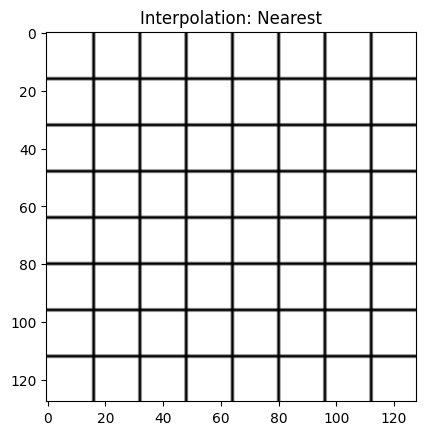

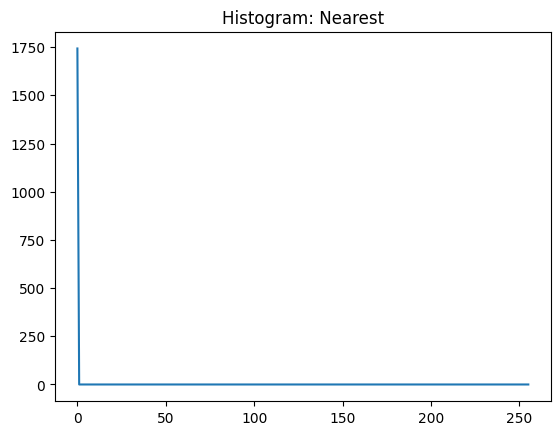

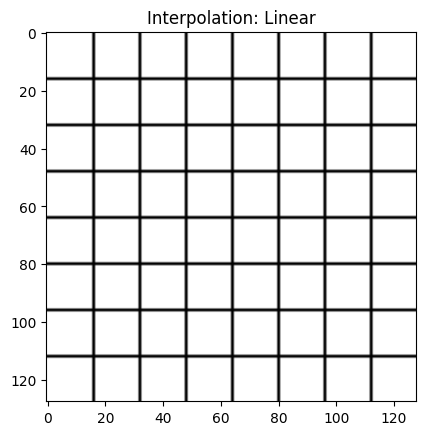

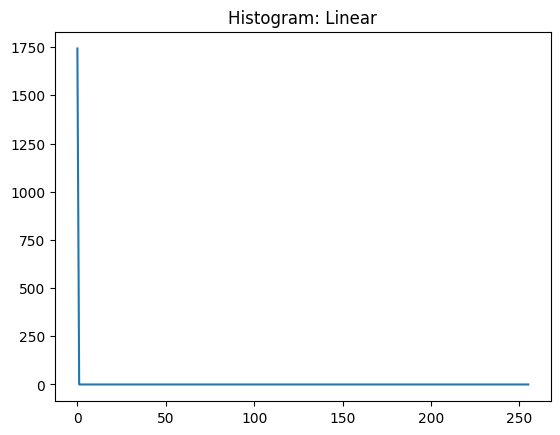

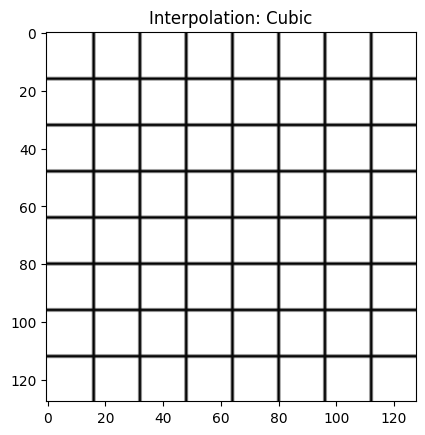

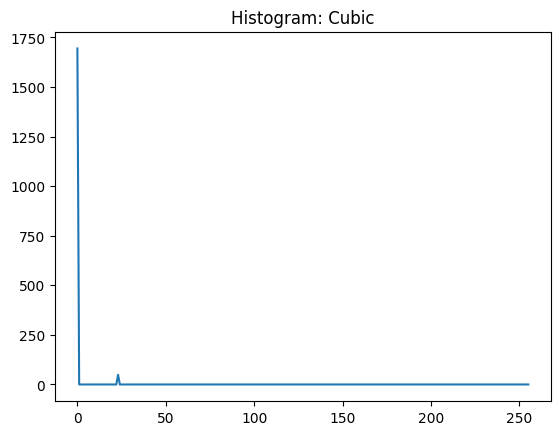

In [3]:
cuad = np.array(cuad, dtype=np.uint8)

cuad_r_2 = cv2.resize(cuad, (128, 128), interpolation=cv2.INTER_LINEAR)
cuad_r_3 = cv2.resize(cuad, (128, 128), interpolation=cv2.INTER_CUBIC)


plt.imshow(cuad_r, cmap='gray', vmin=0, vmax=255)
plt.title('Interpolation: Nearest')
plt.show()

hist_cuad_r = cv2.calcHist([np.array(cuad_r, dtype=np.uint8)], [0], None, [256], [0, 100])
plt.plot(hist_cuad_r)
plt.title('Histogram: Nearest')
plt.show()

plt.imshow(cuad_r_2, cmap='gray', vmin=0, vmax=255)
plt.title('Interpolation: Linear')
plt.show()

hist_cuad_r_2 = cv2.calcHist([np.array(cuad_r_2, dtype=np.uint8)], [0], None, [256], [0, 100])
plt.plot(hist_cuad_r_2)
plt.title('Histogram: Linear')
plt.show()

plt.imshow(cuad_r_3, cmap='gray', vmin=0, vmax=255)
plt.title('Interpolation: Cubic')
plt.show()

hist_cuad_r_3 = cv2.calcHist([np.array(cuad_r_3, dtype=np.uint8)], [0], None, [256], [0, 100])
plt.plot(hist_cuad_r_3)
plt.title('Histogram: Cubic')
plt.show()



Se utilizaron 3 metodos.
1. Nearest: utiliza el pixel más cercano en la imagen original y lo asigna, bueno para imagenes binarias y rectas.
2. Lineal: toma los 4 pixeles más cercanos y a partir de estos calcula el nuevo valor. 
3. cubic: Utiliza los 16 pixeles más cercanos para definir un valor.

Se puede evidenciar que para esta imagen y tamaño tanto el método Nearest como Lineal funcionan de forma similar y utilizan casi que la misma cantidad de grises. Por otro lado, probablemente por la cantidad de casillas blancas al rededor, el método cubic empieza a dar tonos grises en zonas donde no debería ser gris sino negro.


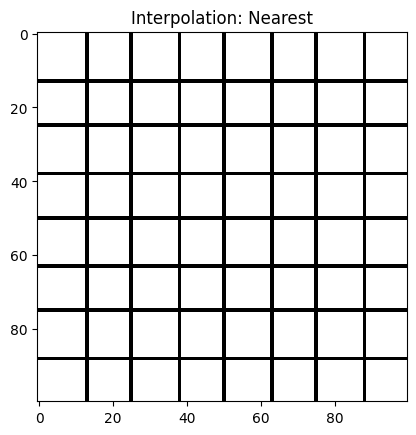

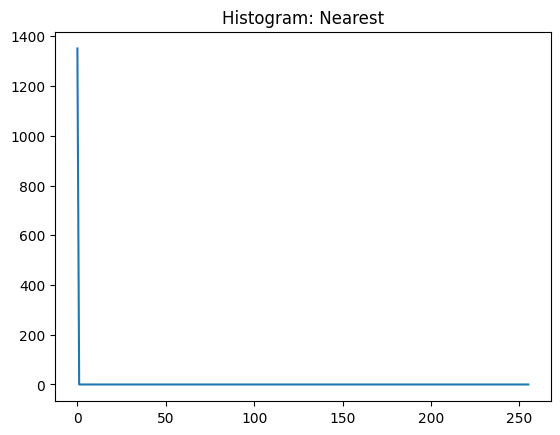

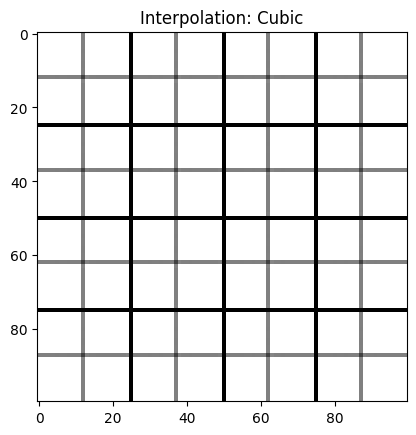

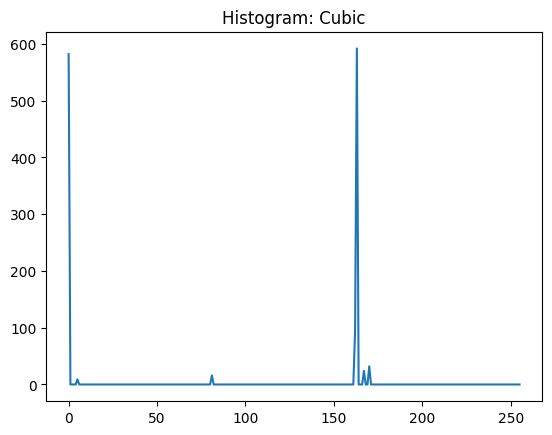

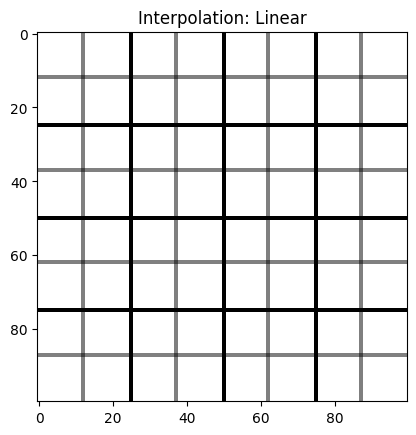

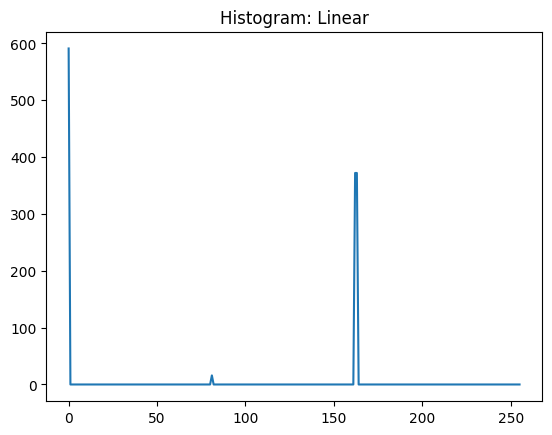

In [4]:
cuad_r_5 = cv2.resize(cuad, (100, 100), interpolation=cv2.INTER_NEAREST)
cuad_r_6 = cv2.resize(cuad, (100, 100), interpolation=cv2.INTER_CUBIC)
cuad_r_7 = cv2.resize(cuad, (100, 100), interpolation=cv2.INTER_LINEAR)

plt.imshow(cuad_r_5, cmap='gray', vmin=0, vmax=255)
plt.title('Interpolation: Nearest')
plt.show()

hist_cuad_r_5 = cv2.calcHist([np.array(cuad_r_5, dtype=np.uint8)], [0], None, [256], [0, 200])
plt.plot(hist_cuad_r_5)
plt.title('Histogram: Nearest')
plt.show()

plt.imshow(cuad_r_6, cmap='gray', vmin=0, vmax=255)
plt.title('Interpolation: Cubic')
plt.show()

hist_cuad_r_6 = cv2.calcHist([np.array(cuad_r_6, dtype=np.uint8)], [0], None, [256], [0, 200])
plt.plot(hist_cuad_r_6)
plt.title('Histogram: Cubic')
plt.show()

plt.imshow(cuad_r_7, cmap='gray', vmin=0, vmax=255)
plt.title('Interpolation: Linear')
plt.show()

hist_cuad_r_7 = cv2.calcHist([np.array(cuad_r_7, dtype=np.uint8)], [0], None, [256], [0, 200])
plt.plot(hist_cuad_r_7)
plt.title('Histogram: Linear')
plt.show()


Para este tamaño de imagenes se puede evidenciar que el mejor método fue Nearest, que gracias a que está trabajando a partir de una imagen binaria, pudo mantener fielmente los colores. Por otro lado, el método linear ya empieza a soltar tonos de grises que no existen, producto de el uso de los pixeles blancos adyacentes. Finalmente, el método cubic también muestra aún más  niveles de grises que no existen y que son el resultado de su interpolación a partir de las casillas en blanco.

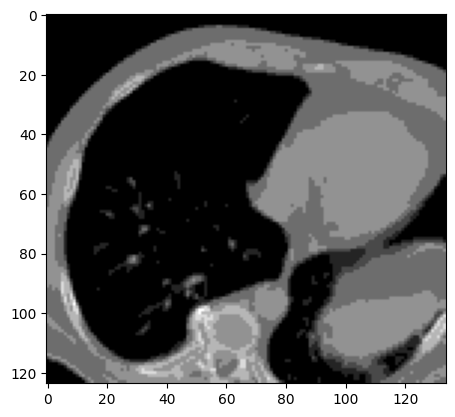

In [5]:
torax = cv2.imread("TORAX.png", cv2.IMREAD_GRAYSCALE)

min_t = np.min(torax)
max_t = np.max(torax)

plt.imshow(torax, cmap='gray', vmin=min_t, vmax=max_t)
plt.show()

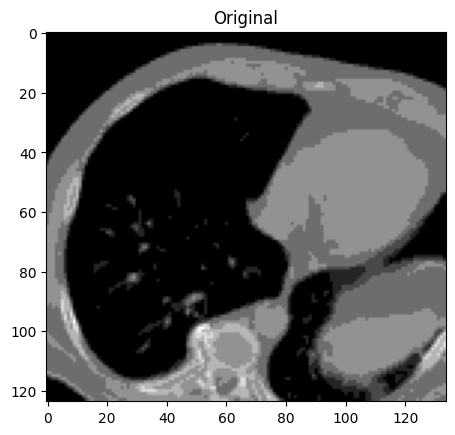

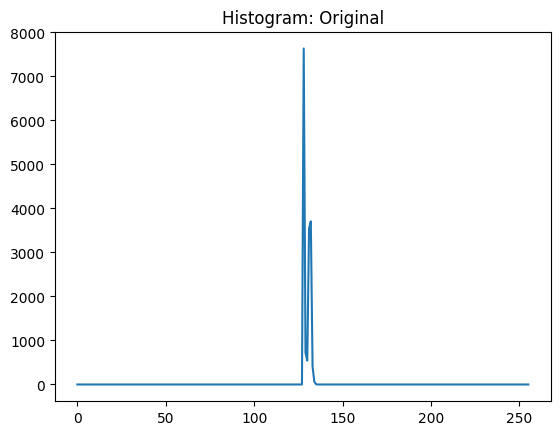

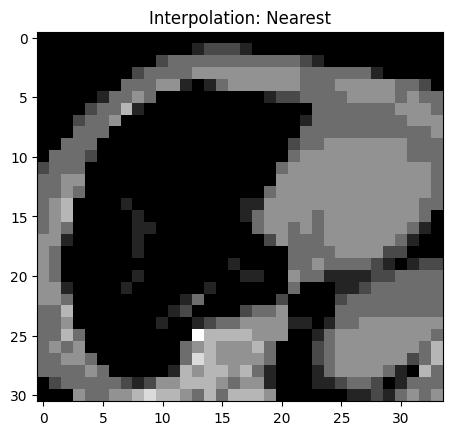

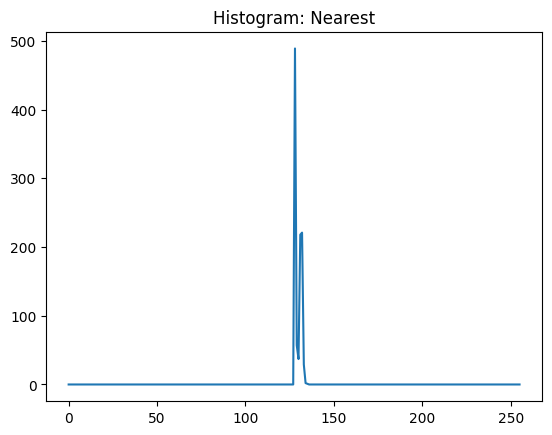

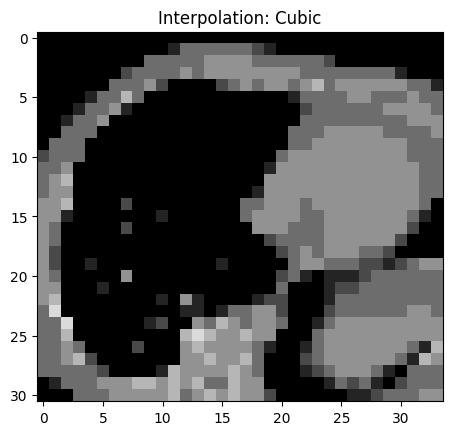

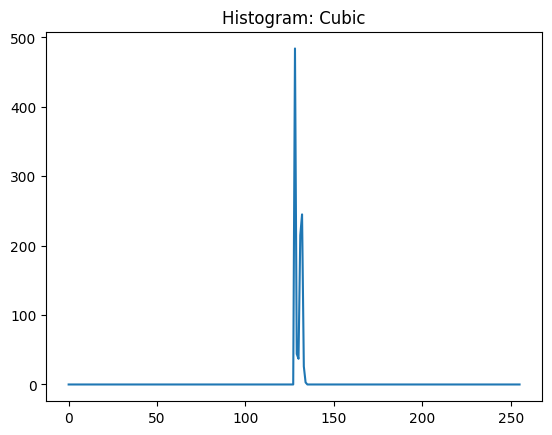

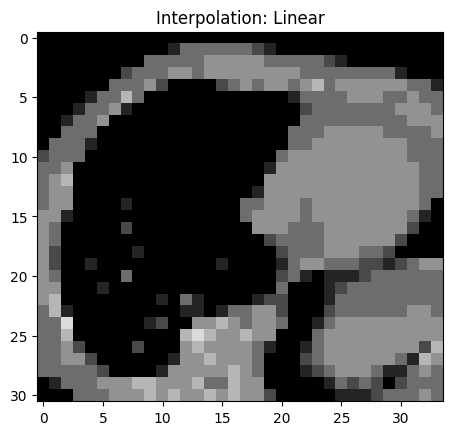

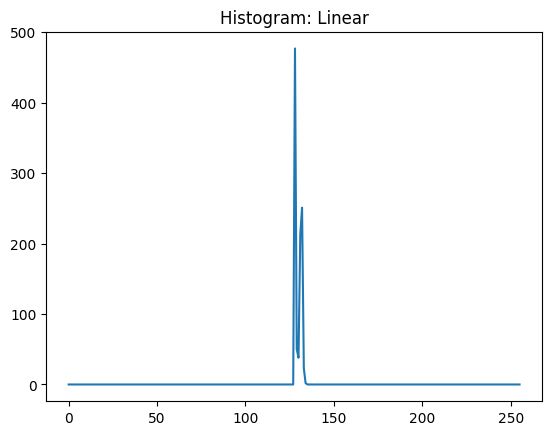

In [6]:
torax_r_1 = cv2.resize(torax, (34, 31), interpolation=cv2.INTER_NEAREST)
torax_r_2 = cv2.resize(torax, (34, 31), interpolation=cv2.INTER_CUBIC)
torax_r_3 = cv2.resize(torax, (34, 31), interpolation=cv2.INTER_LINEAR)

plt.imshow(torax, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Original')
plt.show()

hist_torax = cv2.calcHist([torax], [0], None, [256], [0, 256])
plt.plot(hist_torax)
plt.title('Histogram: Original')
plt.show()

plt.imshow(torax_r_1, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Interpolation: Nearest')
plt.show()

hist_torax_r_1 = cv2.calcHist([torax_r_1], [0], None, [256], [0, 256])
plt.plot(hist_torax_r_1)
plt.title('Histogram: Nearest')
plt.show()


plt.imshow(torax_r_2, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Interpolation: Cubic')
plt.show()

hist_torax_r_2 = cv2.calcHist([torax_r_2], [0], None, [256], [0, 256])
plt.plot(hist_torax_r_2)
plt.title('Histogram: Cubic')
plt.show()


plt.imshow(torax_r_3, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Interpolation: Linear')
plt.show()

hist_torax_r_3 = cv2.calcHist([torax_r_3], [0], None, [256], [0, 256])
plt.plot(hist_torax_r_3)
plt.title('Histogram: Linear')
plt.show()

Gracias al tamaño de la imagen es díficil ver grandes diferencias en la resolucíón de las imagenes, todas se ven pixeladas y mantienen la estructura de la imagen. Sin embargo, aquí se empieza a ver la dificultad del metodo Nearest para mostrar detalles, por lo que no se ven tan bien los puntos blancos dentro del torax. Por otro lado, en el metodo linear sí que se alcanzan a salvar y en el cubic se mantienen aun mejor.

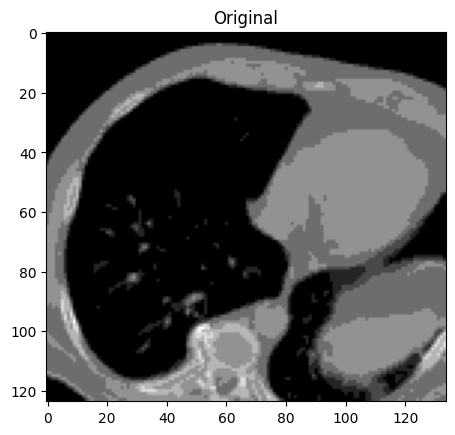

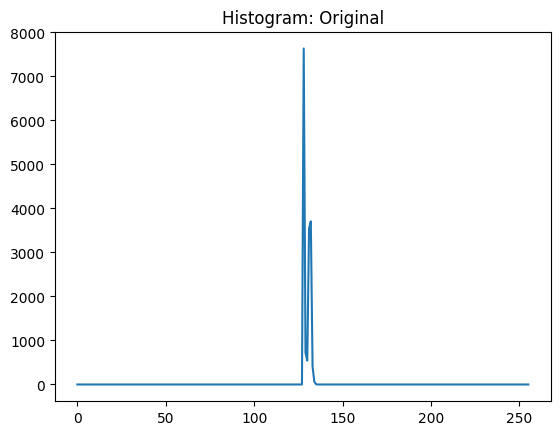

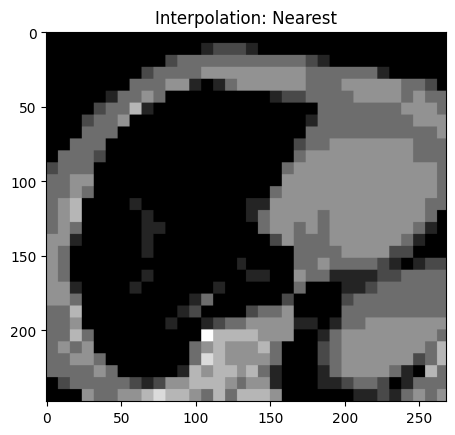

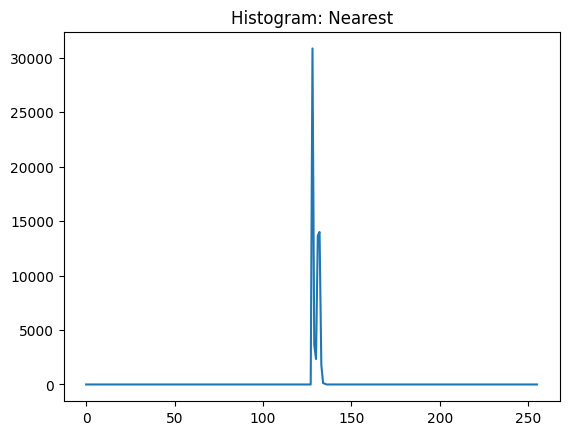

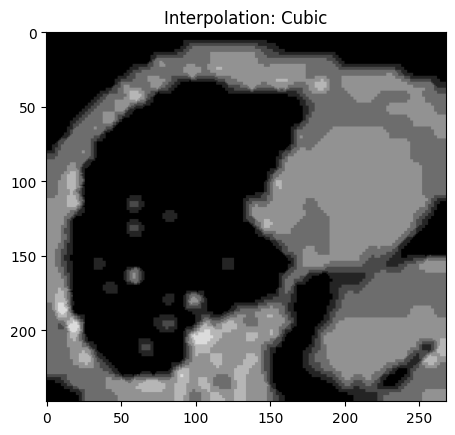

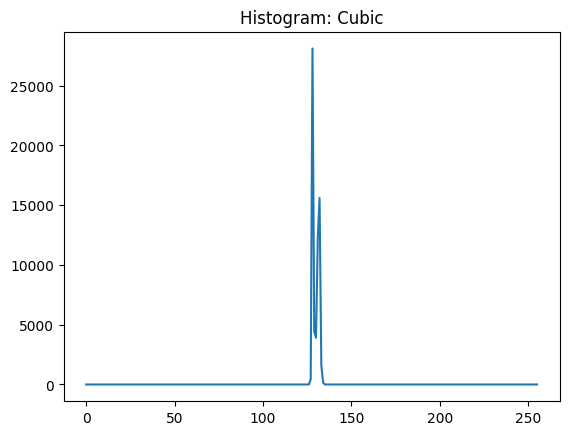

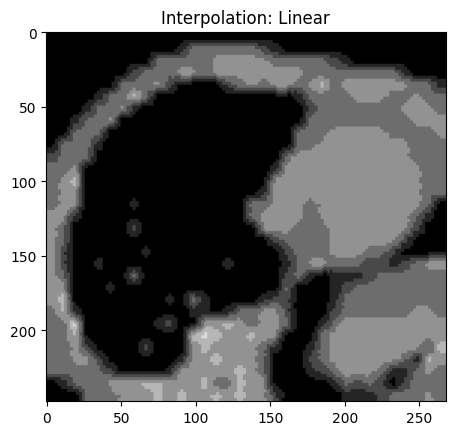

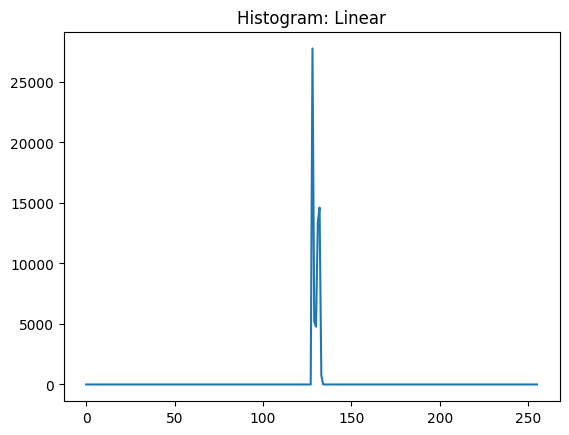

In [7]:
torax_r_4 = cv2.resize(torax_r_1, (134, 124), interpolation=cv2.INTER_NEAREST)
torax_r_4 = cv2.resize(torax_r_4, (2*134, 2*124), interpolation=cv2.INTER_NEAREST)
torax_r_5 = cv2.resize(torax_r_2, (134, 124), interpolation=cv2.INTER_CUBIC)
torax_r_5 = cv2.resize(torax_r_5, (2*134, 2*124), interpolation=cv2.INTER_CUBIC)
torax_r_6 = cv2.resize(torax_r_3, (134, 124), interpolation=cv2.INTER_LINEAR)
torax_r_6 = cv2.resize(torax_r_6, (2*134, 2*124), interpolation=cv2.INTER_LINEAR)

plt.imshow(torax, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Original')
plt.show()

hist_torax = cv2.calcHist([torax], [0], None, [256], [0, 256])
plt.plot(hist_torax)
plt.title('Histogram: Original')
plt.show()

plt.imshow(torax_r_4, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Interpolation: Nearest')
plt.show()

hist_torax_r_4 = cv2.calcHist([torax_r_4], [0], None, [256], [0, 256])
plt.plot(hist_torax_r_4)
plt.title('Histogram: Nearest')
plt.show()

plt.imshow(torax_r_5, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Interpolation: Cubic')
plt.show()

hist_torax_r_5 = cv2.calcHist([torax_r_5], [0], None, [256], [0, 256])
plt.plot(hist_torax_r_5)
plt.title('Histogram: Cubic')
plt.show()

plt.imshow(torax_r_6, cmap='gray', vmin=min_t, vmax=max_t)
plt.title('Interpolation: Linear')
plt.show()

hist_torax_r_6 = cv2.calcHist([torax_r_6], [0], None, [256], [0, 256])
plt.plot(hist_torax_r_6)
plt.title('Histogram: Linear')
plt.show()


En cuanto a la resolución la imagen original era de 134x124 píxeles con un tamaño de píxel de nxn cm.
Después de duplicar la dimensión a 268x248 píxeles, el tamaño del píxel se reduce a (n/2)x(n/2) cm, es decir, se disminuyó el tamaño del pixel y dublicó la resolución.

Además, se evidencia que al reescalar las imagenes el metodo linear pierde calidad y mantiene imagenes pixeladas, probablemente porque no tiene en cuenta pixeles más allá de los adyacentes. El nearest alcanza a representar bien los colores, sin embargo se empiezan a notar que los borden son muy rigidos y rectos, algo que no pasa tanto en los demás metodos. Esto sucede gracias a que utiliza los mismos colores de la imagen original, por lo que no puede suavizar los bordes. El cubic es el que mejor representa, ya que se ve una buena representación de los colores y además los bordes se ven suavizados gracias a la cantidad de datos que tiene en cuenta para cada pixel.

En conclusión, cubic es bueno para imagenes con curvas y varios tonos de intensidad y nearest neighbor es bueno para imagenes binarias con angulos más rectos.

